# Mass attenuation coefficients example
Fetch the attenuation coefficients for a typical air composition, and plot them.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import quantity_support

from adetsim import matter


In [2]:
# Absolute values don't matter, just relative amounts
air_composition = {
    "N": 7.81,
    "O": 2.09,
    "Ar": 0.01,
    "C": 0.001,
}

# By default, only photoelectric absorption is enabled.
air_mcoef = matter.Attenuations.from_compound_dict(air_composition)
air_mcoef

Attenuations[N_0.76|O_0.23|Ar_0.00|C_0.00, photoelectric]

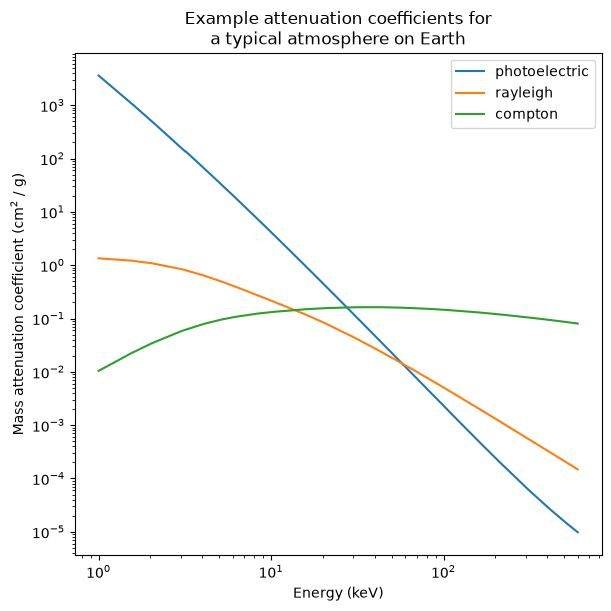

In [3]:
fig, ax = plt.subplots(layout="constrained", figsize=(6, 6))

energies = np.geomspace(1, 600, num=1000) << u.keV

# Save attenuation for each individual type available
air_mcoef.compton = False
air_mcoef.rayleigh = False
air_mcoef.photoelectric = True
results: dict[str, u.Quantity] = dict()
results["photoelectric"] = air_mcoef(energies)

air_mcoef.photoelectric = False
air_mcoef.rayleigh = True
results["rayleigh"] = air_mcoef(energies)

air_mcoef.rayleigh = False
air_mcoef.compton = True
results["compton"] = air_mcoef(energies)

with quantity_support():
    for (name, values) in results.items():
        ax.plot(energies, values, label=name)

ax.legend()
ax.set(
    title="Example attenuation coefficients for\na typical atmosphere on Earth",
    xlabel="Energy (keV)",
    ylabel="Mass attenuation coefficient (cm$^2$ / g)",
    xscale="log",
    yscale="log",
)
plt.show()